Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* ResNet Included
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock, Shortcut
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  133


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  29


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

### Adding 100 blocks (MaxPool2D in each 20 block)

In [7]:
out_channels = 8
size = 64

model_blocks = [
    nn.Conv2d(3, out_channels, 3, 1, 1),
    nn.BatchNorm2d(out_channels),
    nn.ReLU()
]

for stage in range(5):

    for i in range(20):

        conv = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        bn = nn.BatchNorm2d(out_channels)

        model_blocks.append(
            ResidualBlock([conv, bn, nn.ReLU()])
        )

    if stage < 3:
        model_blocks.append(nn.MaxPool2d(2, 2))
        size //= 2

    if stage < 4:
        new_channels = out_channels * 2

        model_blocks.append(
            ResidualBlock(
                [
                    nn.Conv2d(out_channels, new_channels, 3, 1, 1),
                    nn.BatchNorm2d(new_channels),
                    nn.ReLU()
                ],
                Shortcut(out_channels, new_channels)
            )
        )

        out_channels = new_channels


print(f"Final Out Channels = {out_channels}")
print(f"Final Shape = {size}")

Final Out Channels = 128
Final Shape = 8


In [8]:
model = model.add(
    # Conv Blocks
    *model_blocks,
    
    # Flatten
    nn.Flatten(),

    nn.Linear(out_channels * size * size, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
    )

### Use Trainer to train and check validations
Adding weight decay and decreased weight

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

In [10]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment8/",
    save_checkpoints=10,
    print_every=5
    )

In [11]:
history = trainer.fit(100)

Epoch [5/100] | Train Loss: 0.9961 | Val Loss: 0.9762 | Train Acc: 0.5151 | Val Acc: 0.5442 | Train F1: 0.5066 | Val F1: 0.5022
Epoch [10/100] | Train Loss: 0.8422 | Val Loss: 0.8873 | Train Acc: 0.6158 | Val Acc: 0.6084 | Train F1: 0.6165 | Val F1: 0.6063
Epoch [15/100] | Train Loss: 0.7171 | Val Loss: 0.8135 | Train Acc: 0.6857 | Val Acc: 0.6726 | Train F1: 0.6881 | Val F1: 0.6741
Epoch [20/100] | Train Loss: 0.6297 | Val Loss: 0.8205 | Train Acc: 0.7368 | Val Acc: 0.6372 | Train F1: 0.7377 | Val F1: 0.6238
Epoch [25/100] | Train Loss: 0.5982 | Val Loss: 1.2110 | Train Acc: 0.7495 | Val Acc: 0.5044 | Train F1: 0.7502 | Val F1: 0.4667
Epoch [30/100] | Train Loss: 0.5028 | Val Loss: 0.9730 | Train Acc: 0.7944 | Val Acc: 0.5996 | Train F1: 0.7968 | Val F1: 0.5492
Epoch [35/100] | Train Loss: 0.4069 | Val Loss: 0.7435 | Train Acc: 0.8318 | Val Acc: 0.7456 | Train F1: 0.8341 | Val F1: 0.7459
Epoch [40/100] | Train Loss: 0.3979 | Val Loss: 2.5182 | Train Acc: 0.8440 | Val Acc: 0.4226 | Tra

### Save Metrics

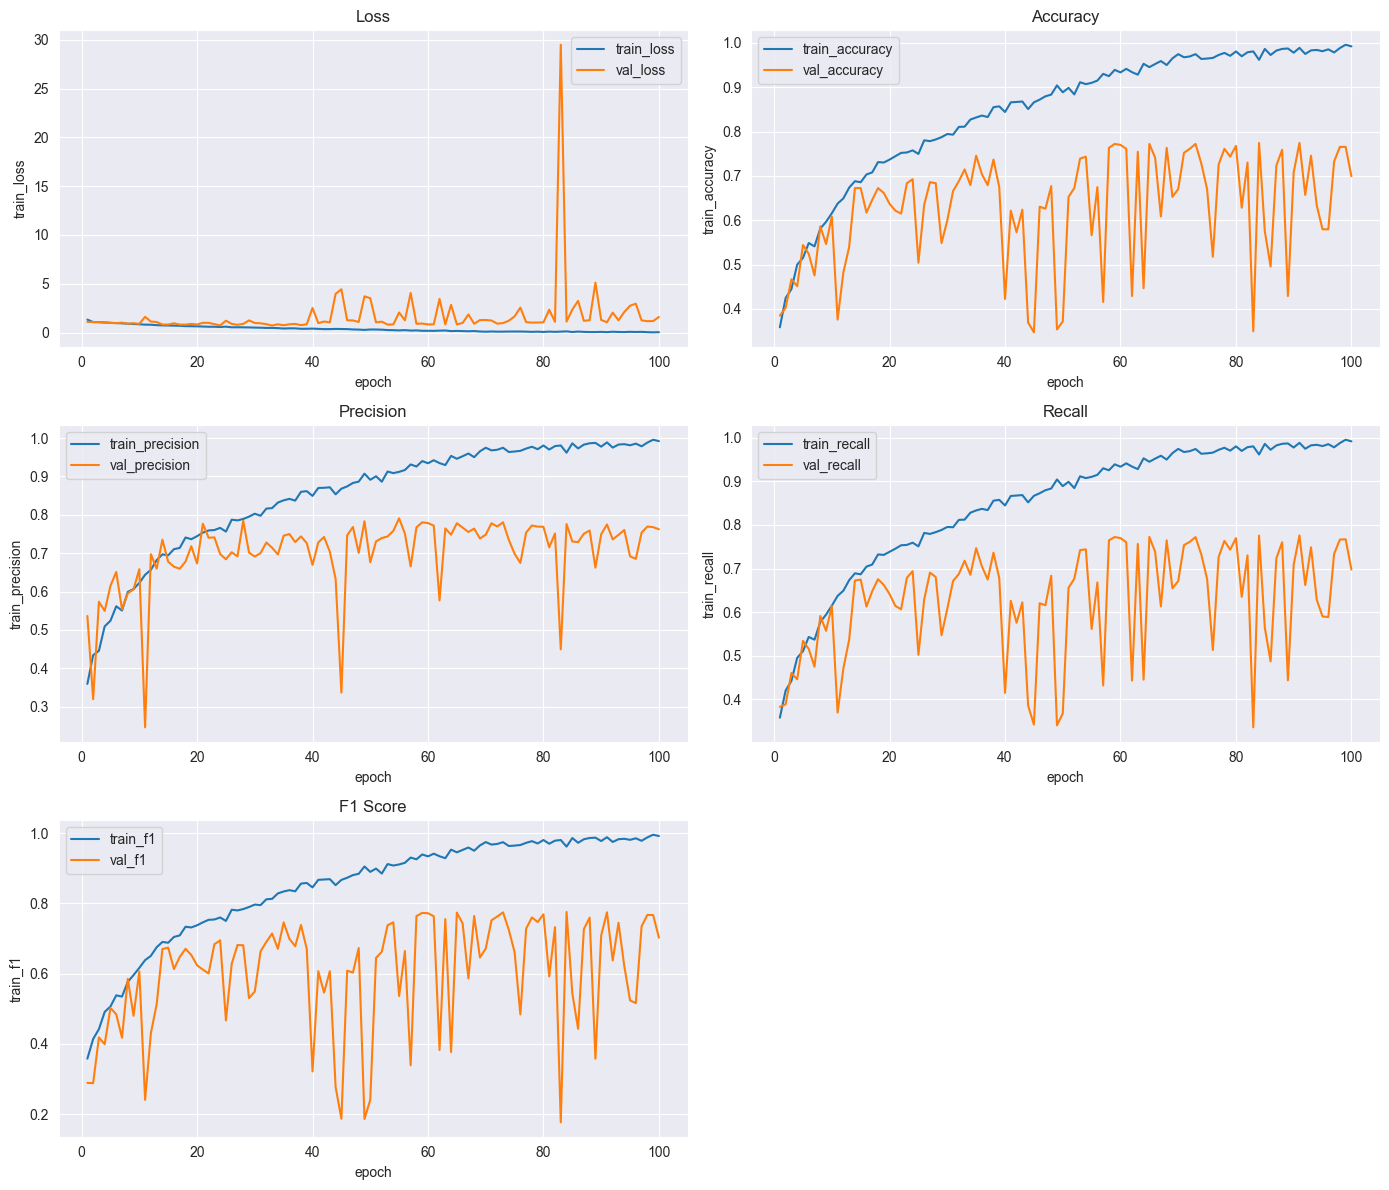

In [12]:
df = plot_training_metrics(history)
df.to_csv("../documentations/experiments/experiment8/tables/training_metrics.csv", index=False)

### Training/Validation Trend (100 epochs)
* Training loss shows a consistent overall downward trend from ~1.32 to ~0.03–0.06 range, indicating effective optimization.
* Training accuracy steadily increases, moving from ~0.35 to peaks above 0.99, showing strong memorization capacity.
* Validation accuracy improves initially, becomes stable in mid-epochs, and fluctuates in later stages.
* Validation loss is highly unstable, with intermittent sharp spikes (notably around epochs 40, 83, 89, 95–96), indicating periodic overfitting or instability.
* Clear overfitting appears after ~80 epochs where train metrics remain near-perfect but validation degrades.
* Best generalization occurs in mid-to-late training range (roughly epochs 58–84).
* Model shows repeated recovery after instability spikes, suggesting non-convergent validation behavior.
* Precision/recall/F1 on training set become saturated (>0.98) in later epochs, indicating ceiling effect.
* Validation metrics plateau around ~0.74–0.77 F1 at best, showing limited generalization gap closure.
* Performance becomes unstable after prolonged training, with diminishing returns beyond ~70 epochs.

The model learns effectively, as shown by the steady reduction in training loss and rapid improvement in training accuracy, eventually reaching near-perfect performance. However, validation metrics improve only up to a point and then plateau, with repeated instability and sharp degradation episodes, indicating overfitting and sensitivity to training dynamics. The best generalization is achieved in the mid-to-late training phase, after which continued training primarily improves training fit rather than real-world performance. The widening gap between training and validation performance in later epochs confirms that the model begins to over-specialize, and optimal performance occurs before full convergence of training metrics.

<b>Best Epoch 84</b>

<b>Loss</b>
* Train Loss = 0.11835905877414643
* Valid Loss = 1.1191416830426595

<b>Training Metrics</b>
* Train Accuracy = 0.9617202281951904
* Train Precison = 0.9619541168212891
* Train Recall = 0.9618192315101624
* Train F1 = 0.9618772864341736

<b>Validation Accuracy</b>
* Validation Accuracy = 0.7743362784385681
* Validation Precision = 0.7758584022521973
* Validation Recall = 0.7756655812263489
* Validation F1 = 0.7757452130317688

## Use Tester Module to Test Model

Load Model with State Dict

In [15]:
# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

tester = Tester(
    model,
    test_loader,
    3,
    torch.nn.CrossEntropyLoss(),
    "cuda"
)

test_scores = tester.test_all_checkpoints(
    "../models/experiment8"
)

Finished testing epoch 1
Finished testing epoch 2
Finished testing epoch 3
Finished testing epoch 5
Finished testing epoch 8
Finished testing epoch 10
Finished testing epoch 14
Finished testing epoch 15
Finished testing epoch 20
Finished testing epoch 23
Finished testing epoch 24
Finished testing epoch 30
Finished testing epoch 33
Finished testing epoch 35
Finished testing epoch 40
Finished testing epoch 50
Finished testing epoch 54
Finished testing epoch 58
Finished testing epoch 59
Finished testing epoch 60
Finished testing epoch 65
Finished testing epoch 70
Finished testing epoch 73
Finished testing epoch 80
Finished testing epoch 84
Finished testing epoch 90
Finished testing epoch 100


### Save Test Metrics

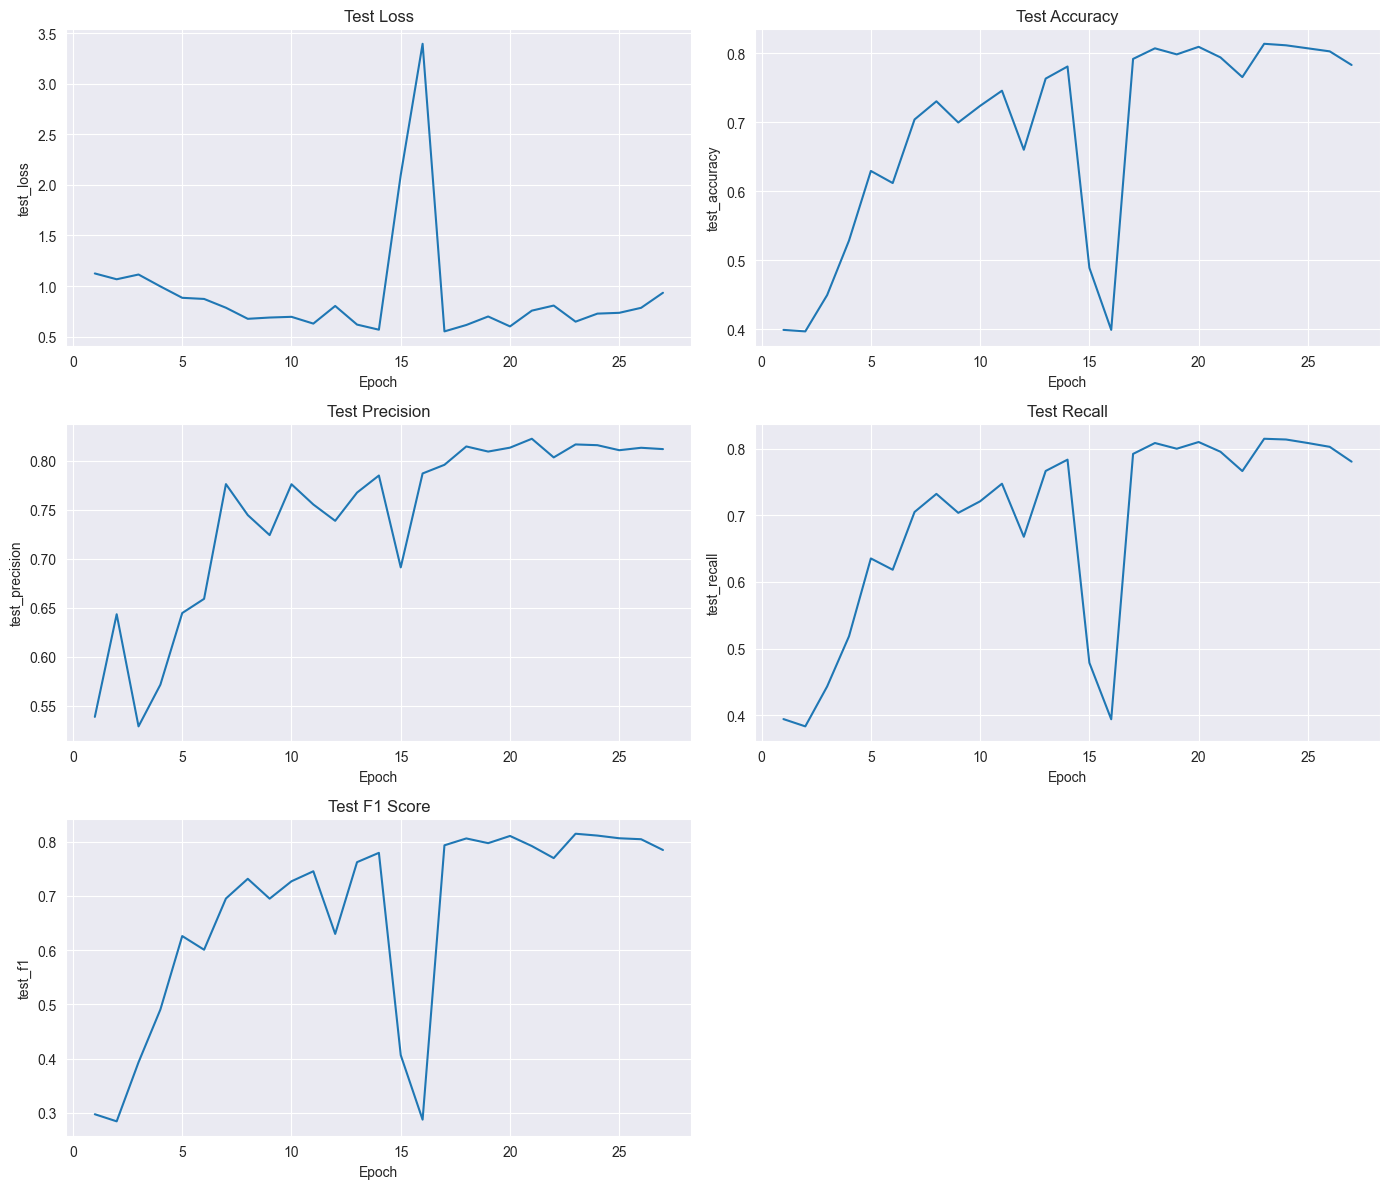

In [17]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/experiments/experiment8/tables/test_metrics.csv", index=False)

### Test Performance Trend
* rapid learning phase in early epochs with steady improvement in accuracy and F1 until about epoch 5–8
* unstable optimization phase around epochs 15–16 with extreme loss spikes and sharp performance degradation
* recovery phase after instability with fast regain of performance from epoch 17 onward
* stable convergence region from roughly epoch 17 to 24 with consistently high accuracy and F1
* mild performance oscillations in later epochs (25–27) indicating saturation and slight instability
* general upward trend in precision across training with occasional overshoot compared to recall
* recall closely tracking accuracy after mid-training stabilization
* loss generally decreasing over time but with occasional large divergence events
* best performance concentrated in mid-late training window rather than final epoch
* diminishing returns after reaching ~0.80 accuracy level

Overall, the training shows a typical convergence pattern with an early learning phase, a mid-training instability likely caused by optimization dynamics (e.g., learning rate sensitivity or batch variance), followed by a stable convergence phase where the model reaches its best generalization performance. After epoch 17, metrics stabilize and remain consistently strong, with only minor fluctuations. The best-performing region is epochs 18–24, after which performance slightly degrades or plateaus, suggesting the model begins to saturate rather than improve further. The presence of a sharp degradation around epochs 15–16 indicates a transient instability rather than long-term divergence, since recovery is strong and sustained.

<b>Best Epoch 23</b>

* Loss = 0.6478886659546145
* Accuracy = 0.8135964870452881
* Precision = 0.8167217373847961
* Recall = 0.8146975040435791
* F1-Score = 0.8147904276847839